# Volleyball - Dynamic Programming

In [31]:
import tkinter as tk
import threading
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [32]:
# Grid / Environment constants
ROWS, COLS = 5, 9
CELL = 80
START = (2, 1)
OUTCOME = (2, 7)
ACTION_COL = 4
ACTION_ROWS = {
    'pass': 0,
    'emergency': 1,
    'dump': 2,
    'quick': 3,
    'high': 4,
}
MOVES = ['right','down','left','up']

ROW_OPTIONS = ['front','back']
PASS_OPTIONS = ['good','bad']
BLOCK_OPTIONS = ['blockers','noblockers']

def is_action_tile(r,c):
    return c == ACTION_COL and r in ACTION_ROWS.values()

def action_from_rc(r,c):
    if c != ACTION_COL: return None
    for name, rr in ACTION_ROWS.items():
        if rr == r: return name
    return None

def legal_action(row, pass_quality, action):
    if action == 'dump' and row == 'back':
        return False
    if pass_quality == 'good':
        return action in {'high','quick','dump','pass'} if row=='front' else action in {'high','quick','pass'}
    else:
        return action in {'emergency','dump','pass'} if row=='front' else action in {'emergency','pass'}

def success_probability(row, pass_quality, blockers, action):
    probs = { 'high':0.5, 'quick':0.5, 'dump':0.3, 'emergency':0.4, 'pass':0.0 }
    if pass_quality == 'bad':
        if row == 'back':
            if blockers == 'blockers':
                probs['emergency'] = 0.25
            else:
                probs['emergency'] = 0.55
        else:
            if blockers == 'blockers':
                probs['emergency'] = 0.6; probs['dump'] = 0.25
            else:
                probs['dump'] = 0.8; probs['emergency'] = 0.5
    else:
        if blockers == 'blockers':
            probs['quick'] = 0.65; probs['high']  = 0.65
            if row=='front': probs['dump'] = 0.4
        else:
            probs['quick'] = 0.85; probs['high']  = 0.85
            if row=='front': probs['dump'] = 0.8
    return probs.get(action, 0.0)

STEP_PENALTY = -0.01
ILLEGAL_PENALTY = -1.0
SECOND_DECISION_PENALTY = -1.0
REVISIT_SAME_DECISION_PENALTY = -0.5
NO_ACTION_AT_GOAL = -0.5
PASS_REWARD = -0.2
EMERGENCY_WHEN_GOOD = -0.3


In [ ]:
# DP state, transitions, value iteration
ACTIONS_LIST = [None, 'pass','emergency','dump','quick','high']

def all_states():
    for r in range(ROWS):
        for c in range(COLS):
            for row in ROW_OPTIONS:
                for pq in PASS_OPTIONS:
                    for bl in BLOCK_OPTIONS:
                        for chosen in ACTIONS_LIST:
                            yield (r,c,row,pq,bl,chosen)

def move_pos(r,c,move):
    if move=='up':    return max(0,r-1), c
    if move=='down':  return min(ROWS-1,r+1), c
    if move=='left':  return r, max(0,c-1)
    if move=='right': return r, min(COLS-1,c+1)
    return r,c

def transitions(s, a):
    r,c,row,pq,bl,chosen = s
    nr,nc = move_pos(r,c,a)
    reward = STEP_PENALTY
    done = False
    next_chosen = chosen

    if is_action_tile(nr,nc):
        act = action_from_rc(nr,nc)
        if chosen is None:
            if not legal_action(row,pq,act):
                reward += ILLEGAL_PENALTY; done = True
            else:
                next_chosen = act
        else:
            if act == chosen: reward += REVISIT_SAME_DECISION_PENALTY
            else: reward += SECOND_DECISION_PENALTY
            # do not terminate to allow progress

    if (nr,nc) == OUTCOME and not done:
        if next_chosen is None: reward += NO_ACTION_AT_GOAL
        elif next_chosen == 'pass': reward += PASS_REWARD
        elif next_chosen == 'emergency' and pq=='good': reward += EMERGENCY_WHEN_GOOD
        else:
            p = success_probability(row,pq,bl,next_chosen); reward += 2*p - 1
        done = True

    ns = (nr,nc,row,pq,bl,next_chosen)
    return [(ns, 1.0, reward, done)]

class ValueIteration:
    def __init__(self, gamma=0.95, theta=1e-6):
        self.gamma = gamma; self.theta = theta
        self.V = defaultdict(float); self.policy = {}
        self.deltas = []; self.value_trace = []
        self.iteration = 0

    def is_terminal_state(self, s):
        r,c,_,_,_,_ = s; return (r,c) == OUTCOME

#! BELMANN EQUATION
    def iterate_once(self):
        delta = 0.0
        newV = defaultdict(float)
        for s in all_states():
            if self.is_terminal_state(s):
                newV[s] = 0.0; continue
            best = -1e9; best_a = None
            for a in MOVES:
                val = 0.0
                for ns, p, r, done in transitions(s,a):
                    val += p * (r + (0.0 if done else self.gamma * self.V[ns]))
                if val > best: best = val; best_a = a
            newV[s] = best; self.policy[s] = best_a
            delta = max(delta, abs(newV[s]-self.V[s]))
        self.V = newV
        self.deltas.append(delta)
        self.value_trace.append(np.mean(list(self.V.values())) if self.V else 0.0)
        self.iteration += 1
        return delta

    def run(self, max_iters=2000, verbose=True):
        it = 0
        while it < max_iters:
            delta = self.iterate_once()
            if verbose and (it+1) % 100 == 0: print(f'Iter {it+1}, delta={delta:.6f}')
            if delta < self.theta:
                if verbose: print(f'Converged at iter {it+1} (delta={delta:.2e})')
                break
            it += 1
        return self.policy

def greedy_action(policy, s):
    a = policy.get(s)
    if a is not None:
        r, c, row, pq, bl, chosen = s
        if chosen is not None and c == ACTION_COL and a in ['up','down']:
            return 'right'
        return a
    r, c, row, pq, bl, chosen = s
    target_c = ACTION_COL if chosen is None else OUTCOME[1]
    if c < target_c: return 'right'
    if c > target_c: return 'left'
    if chosen is None:
        action_rows = list(ACTION_ROWS.values())
        target_r = min(action_rows, key=lambda rr: abs(rr - r))
    else:
        target_r = OUTCOME[0]
    if r < target_r: return 'down'
    if r > target_r: return 'up'
    return 'right'


In [34]:
# Simulation helpers
def reset_random_conditions():
    return random.choice(ROW_OPTIONS), random.choice(PASS_OPTIONS), random.choice(BLOCK_OPTIONS)

def run_episode(policy, max_steps=200):
    row,pq,bl = reset_random_conditions()
    s = (START[0], START[1], row, pq, bl, None)
    total = 0.0; steps = 0; done = False
    while not done and steps < max_steps:
        a = greedy_action(policy, s)
        ns, p, r, done = transitions(s,a)[0]
        total += r; s = ns; steps += 1
    return total, steps


In [35]:
# State-value heatmaps
def grid_values_for(vi, row, pq, bl, chosen=None):
    M = np.zeros((ROWS, COLS), dtype=float)
    for r in range(ROWS):
        for c in range(COLS):
            s = (r, c, row, pq, bl, chosen)
            M[r, c] = vi.V.get(s, 0.0)
    return M

def plot_state_values_all(vi):
    combos = [
        ('front','good','blockers'), ('front','good','noblockers'),
        ('front','bad','blockers'),  ('front','bad','noblockers'),
        ('back','good','blockers'),  ('back','good','noblockers'),
        ('back','bad','blockers'),   ('back','bad','noblockers'),
    ]
    mats = [grid_values_for(vi, row, pq, bl, chosen=None) for (row, pq, bl) in combos]
    all_vals = np.concatenate([m.flatten() for m in mats])
    vmin, vmax = float(np.min(all_vals)), float(np.max(all_vals))
    if vmin == vmax: vmin, vmax = vmin-1e-6, vmax+1e-6
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)
    axes = axes.ravel()
    for ax, (row, pq, bl), M in zip(axes, combos, mats):
        im = ax.imshow(M, cmap='coolwarm', vmin=vmin, vmax=vmax, origin='upper', interpolation='nearest')
        ax.set_title(f'{row}, {pq}, {bl}')
        ax.set_xticks(range(COLS)); ax.set_yticks(range(ROWS))
        ax.scatter([START[1]], [START[0]], s=80, c='lime', marker='s', edgecolors='k')
        ax.scatter([OUTCOME[1]], [OUTCOME[0]], s=80, c='yellow', marker='*', edgecolors='k')
    cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.9)
    cbar.set_label('V(s)')
    plt.show()


Iter 100, delta=0.000062
Converged at iter 181 (delta=9.78e-07)
Episode 100: avg reward (last 100) = 0.053
Episode 200: avg reward (last 100) = -0.066
Episode 300: avg reward (last 100) = 0.177


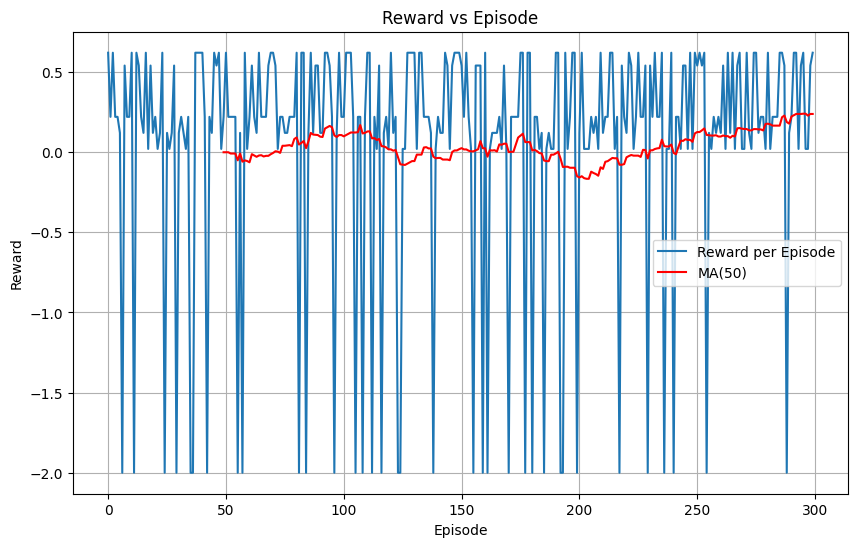

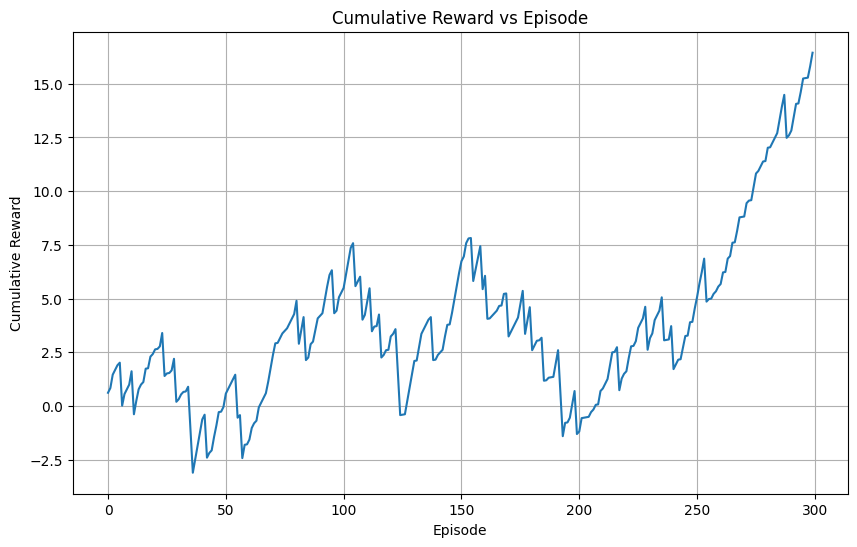

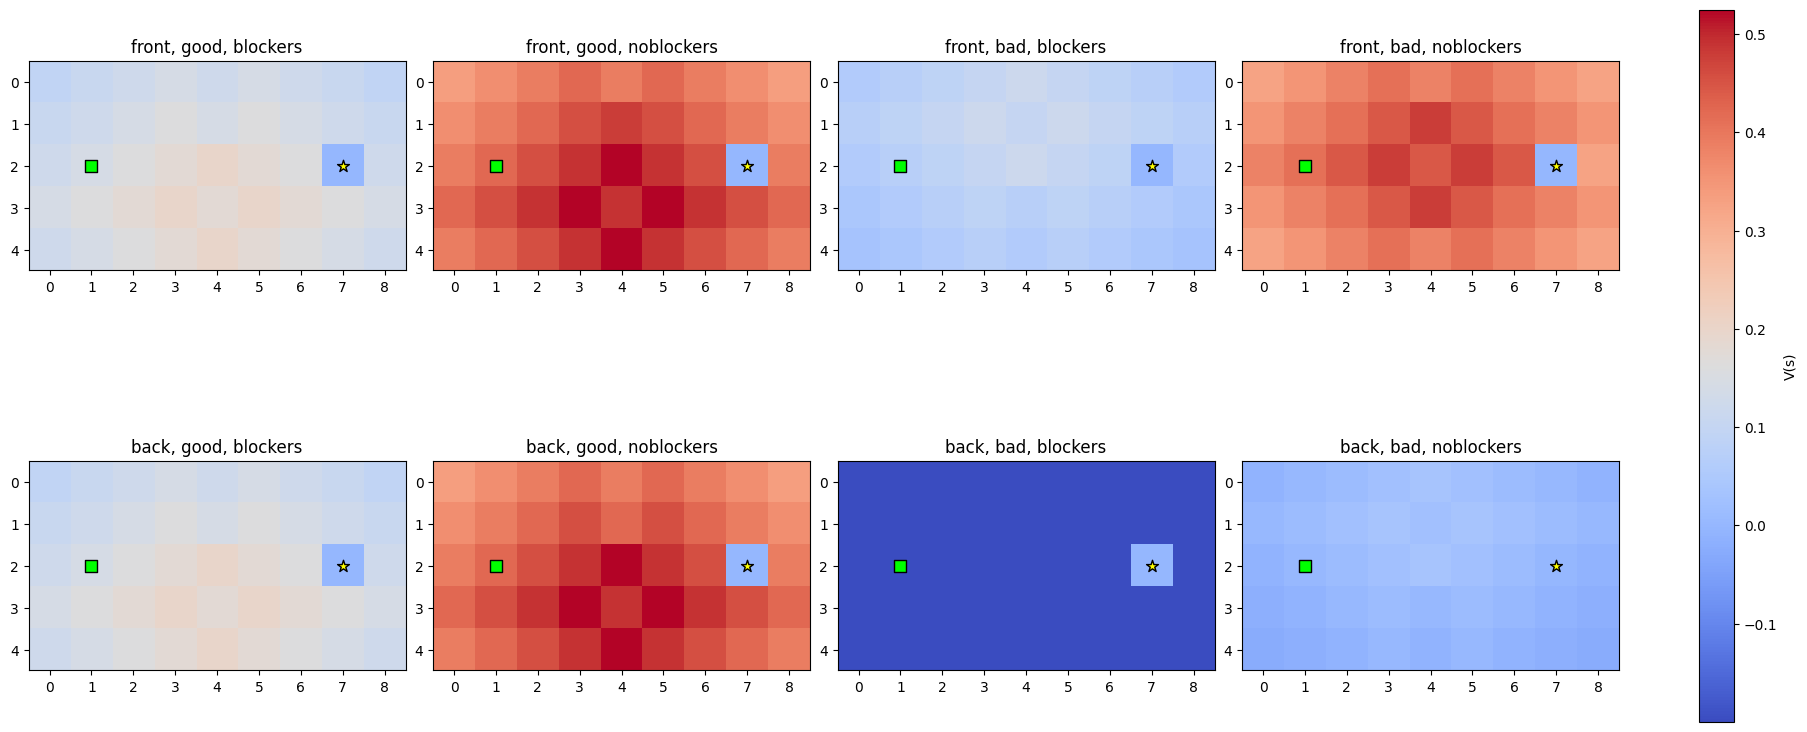

In [36]:
# Tkinter app with conditions visibility + training iteration display
class DPApp:
    def __init__(self):
        self.root = tk.Tk()
        self.root.title('Dynamic Programming - Value Iteration (Animated) v6')
        self.canvas = tk.Canvas(self.root, width=COLS*CELL, height=ROWS*CELL, bg='white')
        self.canvas.pack()
        self.status = tk.Label(self.root, text='Ready', anchor='w')
        self.status.pack(fill='x')
        # Persistent labels for conditions and training progress
        self.cond_label = tk.Label(self.root, text='Conditions: —', anchor='w')
        self.cond_label.pack(fill='x')
        ctl = tk.Frame(self.root); ctl.pack(fill='x')
        self.train_btn = tk.Button(ctl, text='Train Value Iteration', command=self.start_training, bg='#2e7d32', fg='white')
        self.train_btn.pack(side='left', padx=5)
        self.test_btn = tk.Button(ctl, text='Test Policy', command=self.start_testing, bg='#1565c0', fg='white')
        self.test_btn.pack(side='left', padx=5)
        self.demo_btn = tk.Button(ctl, text='Run Demo', command=self.start_demo, bg='#ef6c00', fg='white')
        self.demo_btn.pack(side='left', padx=5)
        self.stop_demo_btn = tk.Button(ctl, text='Stop Demo', command=self.stop_demo, bg='#b71c1c', fg='white')
        self.stop_demo_btn.pack(side='left', padx=5)
        tk.Label(ctl, text='Speed (ms/step)').pack(side='left', padx=(20,4))
        self.speed = tk.Scale(ctl, from_=0, to=800, orient='horizontal'); self.speed.set(200); self.speed.pack(side='left')
        tk.Label(ctl, text='Episodes').pack(side='left', padx=(20,4))
        self.num_episodes = tk.IntVar(value=300)
        self.ep_entry = tk.Spinbox(ctl, from_=1, to=10000, textvariable=self.num_episodes, width=6)
        self.ep_entry.pack(side='left')
        self.graph_btn = tk.Button(ctl, text='Compute Graphs', command=self.show_graphs, bg='#6a1b9a', fg='white')
        self.graph_btn.pack(side='left', padx=5)
        self.draw_board()
        self.agent_token = None
        self.vi = ValueIteration(gamma=0.95, theta=1e-6)
        self.episode_rewards = []
        self.cumulative_rewards = []
        self.running_demo = False
        self.demo_state = None
        self.demo_steps = 0

    def draw_board(self):
        self.canvas.delete('all')
        for r in range(ROWS):
            for c in range(COLS):
                x1,y1 = c*CELL, r*CELL
                x2,y2 = x1+CELL, y1+CELL
                fill = 'white'
                if (r,c)==START: fill = '#c8e6c9'
                if (r,c)==OUTCOME: fill = '#ffcdd2'
                if is_action_tile(r,c): fill = '#fff9c4'
                self.canvas.create_rectangle(x1,y1,x2,y2, fill=fill, outline='black')
                if is_action_tile(r,c):
                    name = action_from_rc(r,c)
                    self.canvas.create_text(x1+CELL/2, y1+CELL/2, text=name.title(), font=('Arial', 11, 'bold'))
        self.canvas.create_text(START[1]*CELL+CELL/2, START[0]*CELL+12, text='START', fill='green')
        self.canvas.create_text(OUTCOME[1]*CELL+CELL/2, OUTCOME[0]*CELL+12, text='OUTCOME', fill='red')

    def draw_agent(self, r, c):
        x1, y1 = c*CELL+12, r*CELL+12
        x2, y2 = x1+CELL-24, y1+CELL-24
        if self.agent_token is None:
            self.agent_token = self.canvas.create_oval(x1, y1, x2, y2, fill='#1f6feb', outline='black')
        else:
            self.canvas.coords(self.agent_token, x1, y1, x2, y2)

    def start_training(self):
        self.status.config(text='Training Value Iteration...')
        self.train_btn.config(state='disabled')
        def work():
            self.vi.run(max_iters=200000, verbose=True)  # or verbose=False if you don’t want console prints
            self.root.after(0, self.training_done)
        threading.Thread(target=work, daemon=True).start()

    def training_done(self):
        self.status.config(text='Training complete. Use Test Policy or Compute Graphs.')
        self.train_btn.config(state='normal')

    def start_testing(self):
        if not self.vi.policy:
            self.status.config(text='Train first.')
            return
        self.episode_rewards.clear(); self.cumulative_rewards.clear()
        self.status.config(text='Testing (running episodes) ...')
        def work():
            total = 0.0
            episodes = max(1, int(self.num_episodes.get()))
            for ep in range(episodes):
                row, pq, bl = reset_random_conditions()
                self.root.after(0, lambda e=ep, cond=(row,pq,bl), n=episodes: self.cond_label.config(text=f'Conditions (test ep {e+1}/{n}): {cond[2]}, {cond[1]}, {cond[0]}'))
                s = (START[0], START[1], row, pq, bl, None)
                rsum = 0.0; steps = 0; done = False
                while not done and steps < 200:
                    a = greedy_action(self.vi.policy, s)
                    ns, p, rwd, done = transitions(s, a)[0]
                    rsum += rwd; s = ns; steps += 1
                total += rsum
                self.episode_rewards.append(rsum)
                self.cumulative_rewards.append(total)
                if (ep+1) % 100 == 0:
                    print(f'Episode {ep+1}: avg reward (last 100) = {np.mean(self.episode_rewards[-100:]):.3f}')
            self.root.after(0, lambda: self.status.config(text='Testing complete. Click Compute Graphs.'))
        threading.Thread(target=work, daemon=True).start()

    def start_demo(self):
        if not self.vi.policy:
            self.status.config(text='Train first to get a policy.')
            return
        if self.running_demo: return
        self.running_demo = True
        row, pq, bl = reset_random_conditions()
        self.demo_state = (START[0], START[1], row, pq, bl, None)
        self.demo_steps = 0
        self.status.config(text='Demo start')
        self.cond_label.config(text=f'Conditions: {bl}, {pq}, {row}')
        self.draw_agent(self.demo_state[0], self.demo_state[1])
        self.schedule_demo_step()

    def stop_demo(self):
        self.running_demo = False
        self.status.config(text='Demo stopped.')

    def schedule_demo_step(self):
        if not self.running_demo: return
        if self.demo_steps > 400:
            row, pq, bl = reset_random_conditions()
            self.demo_state = (START[0], START[1], row, pq, bl, None)
            self.demo_steps = 0
            self.status.config(text='Demo start (step cap)')
            self.cond_label.config(text=f'Conditions: {bl}, {pq}, {row}')
            self.draw_agent(self.demo_state[0], self.demo_state[1])
        s = self.demo_state
        a = greedy_action(self.vi.policy, s)
        ns, p, rwd, done = transitions(s, a)[0]
        if (ns[0], ns[1]) == (s[0], s[1]):
            for alt in ['right','down','left','up']:
                nr_alt, nc_alt = move_pos(s[0], s[1], alt)
                if (nr_alt, nc_alt) != (s[0], s[1]):
                    ns2, p2, r2, done2 = transitions(s, alt)[0]
                    if (ns2[0], ns2[1]) != (s[0], s[1]): ns, rwd, done, a = ns2, r2, done2, alt; break
        self.demo_state = ns
        self.demo_steps += 1
        self.draw_agent(ns[0], ns[1])
        chosen = ns[5]
        self.status.config(text=f'Move: {a}, Reward: {rwd:.2f}' + (f', Chosen: {chosen}' if chosen else ''))
        if done:
            row, pq, bl = reset_random_conditions()
            self.demo_state = (START[0], START[1], row, pq, bl, None)
            self.demo_steps = 0
            self.status.config(text='Demo start (prev terminal)')
            self.cond_label.config(text=f'Conditions: {bl}, {pq}, {row}')
            self.draw_agent(self.demo_state[0], self.demo_state[1])
        delay_ms = int(self.speed.get())
        self.root.after(max(0, delay_ms), self.schedule_demo_step)

    def show_graphs(self):
        if self.episode_rewards:
            plt.figure(figsize=(10,6)); plt.plot(self.episode_rewards, label='Reward per Episode')
            if len(self.episode_rewards) > 20:
                w = 50 if len(self.episode_rewards) >= 50 else max(5, len(self.episode_rewards)//5)
                ma = np.convolve(self.episode_rewards, np.ones(w)/w, mode='valid')
                plt.plot(range(w-1, len(self.episode_rewards)), ma, 'r-', label=f'MA({w})')
            plt.xlabel('Episode'); plt.ylabel('Reward'); plt.title('Reward vs Episode'); plt.grid(True); plt.legend(); plt.show()
        if self.cumulative_rewards:
            plt.figure(figsize=(10,6)); plt.plot(self.cumulative_rewards)
            plt.xlabel('Episode'); plt.ylabel('Cumulative Reward'); plt.title('Cumulative Reward vs Episode'); plt.grid(True); plt.show()
        if self.vi.V:
            plot_state_values_all(self.vi)

    def run(self):
        self.root.mainloop()

DPApp().run()
